In [ ]:
json_path = "D:/sumer/3_YOLO_ultra/runs/detect/val8/predictions.json"
import json

with open(json_path, "r") as f:
    predictions = json.load(f)

char_id_to_unicode_path = "D:/sumer/3_YOLO_ultra/dataset_unicode/dataset.yaml"
import yaml
with open(char_id_to_unicode_path, "r") as f:
    data = yaml.safe_load(f)
char_id_to_unicode = data["names"] # is a list

category_id_to_unicode = {i: char_id_to_unicode[i-1] for i in range(1, len(char_id_to_unicode)+1)}

In [30]:
# each object in predictions is like : {"image_id": "HS_1128_HeiCuBeDa_GMOCF_r1.50_n4_v512_03_front", "file_name": "HS_1128_HeiCuBeDa_GMOCF_r1.50_n4_v512_03_front.png", "category_id": 16, "bbox": [282.812, 54.188, 171.326, 162.429], "score": 0.91933}
# first, regroup by file_name
file_name_to_bboxes = {}
for pred in predictions:
    file_name = pred["file_name"]
    if file_name not in file_name_to_bboxes:
        file_name_to_bboxes[file_name] = []
    pred["unicode"] = category_id_to_unicode[pred["category_id"]]
    file_name_to_bboxes[file_name].append(pred)
    

Visualizing: HS_1178_HeiCuBeDa_GMOCF_r1.50_n4_v512_03_front.png
0 𒀭
1 𒊩𒌆
2 𒂵
3 𒈣
4 𒈗
5 𒀭
6 𒇽
7 𒅇
8 𒇽
9 𒊏
10 𒌉
11 𒌓
12 𒀭
13 𒇽
14 𒂄
15 𒁹
16 𒁹
17 𒌨
18 𒁹
19 𒁹
20 𒁹
21 𒁀
22 𒋽
23 𒁹
24 𒍑


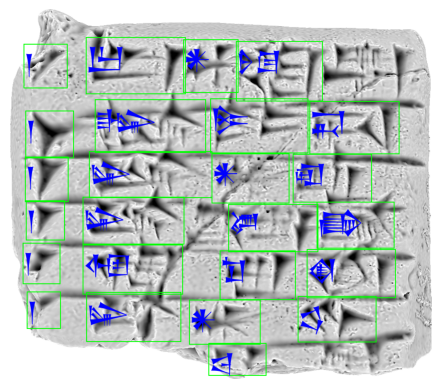

In [31]:
# visualize one example with PIL for Unicode support
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import numpy as np
from CER import filter_bboxes

example_file_name = list(file_name_to_bboxes.keys())[13]
print("Visualizing:", example_file_name)
bboxes = file_name_to_bboxes[example_file_name]
image_path = f"D:/sumer/HeiCuBeDa/Images_MSII_Filter/{example_file_name}"
# HS_1178_HeiCuBeDa_GMOCF_r1.50_n4_v512_03_front.png

# Load image with OpenCV
image = cv2.imread(image_path)

# Convert to PIL image
image_pil = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
draw = ImageDraw.Draw(image_pil)

font = ImageFont.truetype("D:\\sumer\\3_YOLO_ultra\\NotoSansCuneiform-Regular.ttf", 60)  

all_bboxes = []
for bbox in bboxes:
    x, y, w, h = bbox["bbox"]
    all_bboxes.append([x, y, x + w, y + h])
all_texts = [bbox["unicode"] for bbox in bboxes]
filtered_bboxes, filtered_texts = filter_bboxes(all_bboxes, all_texts)
for (i, bbox) in enumerate(filtered_bboxes):
    x1, y1, x2, y2 = map(int, bbox)
    unicode_char = filtered_texts[i]
    print(i, unicode_char)
    
    # Draw rectangle
    draw.rectangle([x1, y1, x2, y2], outline=(0, 255, 0), width=2)
    
    # Draw Unicode text
    draw.text((x1, y1 - 30), f"{unicode_char}", font=font, fill=(0, 0, 255))

# Convert back to OpenCV image for matplotlib display
image = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [32]:
# put to reading order
from CER import reading_order,CER,charnames_to_unicode_string
cers=[]
for (i, (file_name, bboxes)) in enumerate(file_name_to_bboxes.items()):
    
    # from xywh to xyxy
    xyxy_bboxes = []
    for bbox in bboxes:
        x, y, w, h = bbox["bbox"]
        xyxy_bboxes.append([x, y, x + w, y + h])
    ordered_text = reading_order(
        xyxy_bboxes,
        [bbox["unicode"].replace("<OTHER>","?") for bbox in bboxes],
        # [charnames_to_unicode_string(bbox["unicode"].replace("<OTHER>","?")) for bbox in bboxes],
        alpha=0.35
    
    )
    # print(f"{file_name}: {ordered_text}")
    
    # gt is at D:\sumer\3_YOLO_ultra\dataset_unicode\labels\val\{file_name[:-4]}.txt
    gt_path = f"D:\\sumer\\3_YOLO_ultra\\dataset_unicode\\whole_image_unicode\\val\\{file_name[:-4]}.txt"
    with open(gt_path, "r", encoding="utf-8") as f:
        # only one line
        gt_text = f.readline().strip()
    
    
    if len(gt_text) < 1:
        continue
    else:
        cer = CER(ordered_text, gt_text)
        cers.append(cer)
        # print(f"predicted: {ordered_text}, GT: {gt_text}, CER: {cer:.4f}")
    if i == 13:
        print(ordered_text)
        print(gt_text, cer)
    
mean_cer = sum(cers) / len(cers)
print(f"CER available on {len(cers)} images out of {len(file_name_to_bboxes)}")
print(f"Mean CER: {mean_cer:.4f}")

𒁹𒌨𒀭𒊩𒌆𒁹𒈗𒌉𒍑𒁹𒇽𒀭𒊏𒁹𒇽𒂄𒂵𒁹𒅇𒈣𒋽𒁹𒇽𒀭𒌓𒁀
𒁹𒌨𒊩𒌆𒅁𒁹𒈗𒌉𒍑𒁹𒇽𒀭𒊏𒁹𒇽𒊷𒂵𒁹𒅇𒈣𒋽𒁹𒇽𒌓𒆗𒆷 0.23076923076923078
CER available on 123 images out of 211
Mean CER: 0.4652


In [24]:
# 𒌓𒌨𒀭𒊩𒌆𒋞𒁹𒈗𒌉𒍑𒁹𒇽𒀭𒊏𒁹𒇽𒋗𒊷𒂵𒁹𒅇𒈣𒋽𒁹𒇽𒀭𒌓𒁀𒆤